# Phenomenological model constraining: application

![image.png](../../slides/jetset_slides/jetset_slides.025.png)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
from jetset.test_data_helper import  test_SEDs
from jetset.data_loader import ObsData,Data
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs


In [2]:
import jetset
print('tested with',jetset.__version__)

tested with 1.4.0rc3


In [3]:
print(test_SEDs[1])
data=Data.from_file(test_SEDs[2])


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv


In [4]:
%matplotlib inline
from jetset.cosmo_tools import Cosmo
c=Cosmo()
sed_data=ObsData(data_table=data,cosmo=c)
sed_data.group_data(bin_width=0.2)
sed_data.add_systematics(0.2,[10.**6,10.**29])



***  binning data  ***
---> N bins= 88
---> bin_width= 0.2



In [5]:
sed_data.save('Mrk_501.pkl')

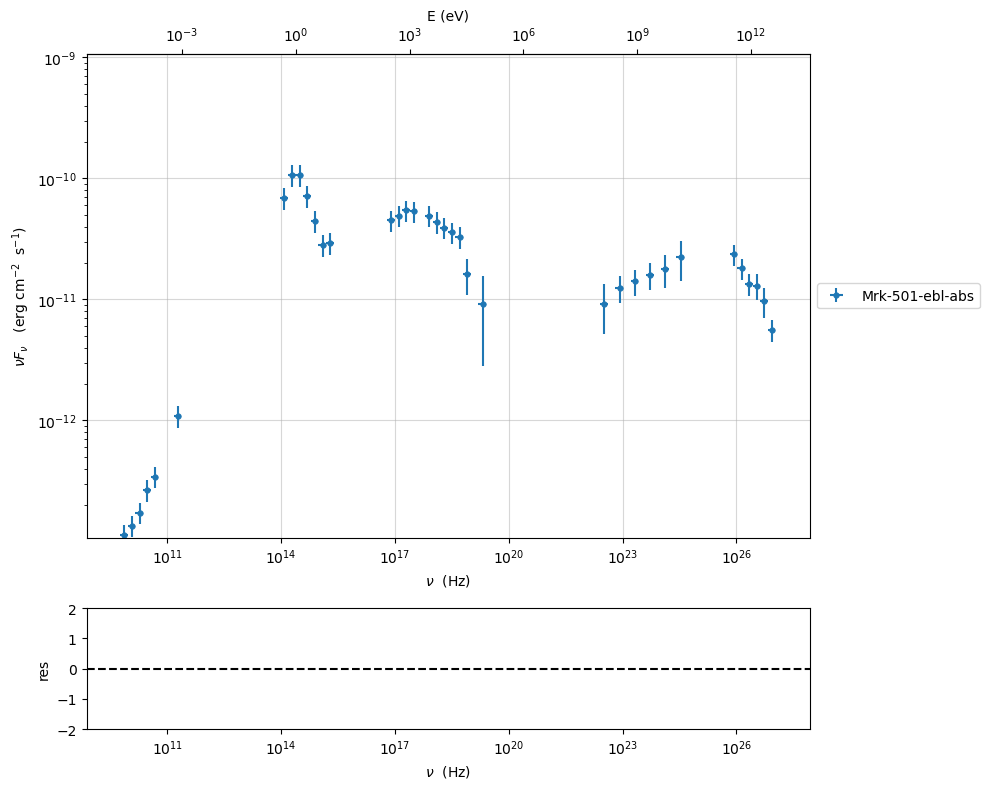

In [6]:
p=sed_data.plot_sed()


*** evaluating spectral indices for data ***



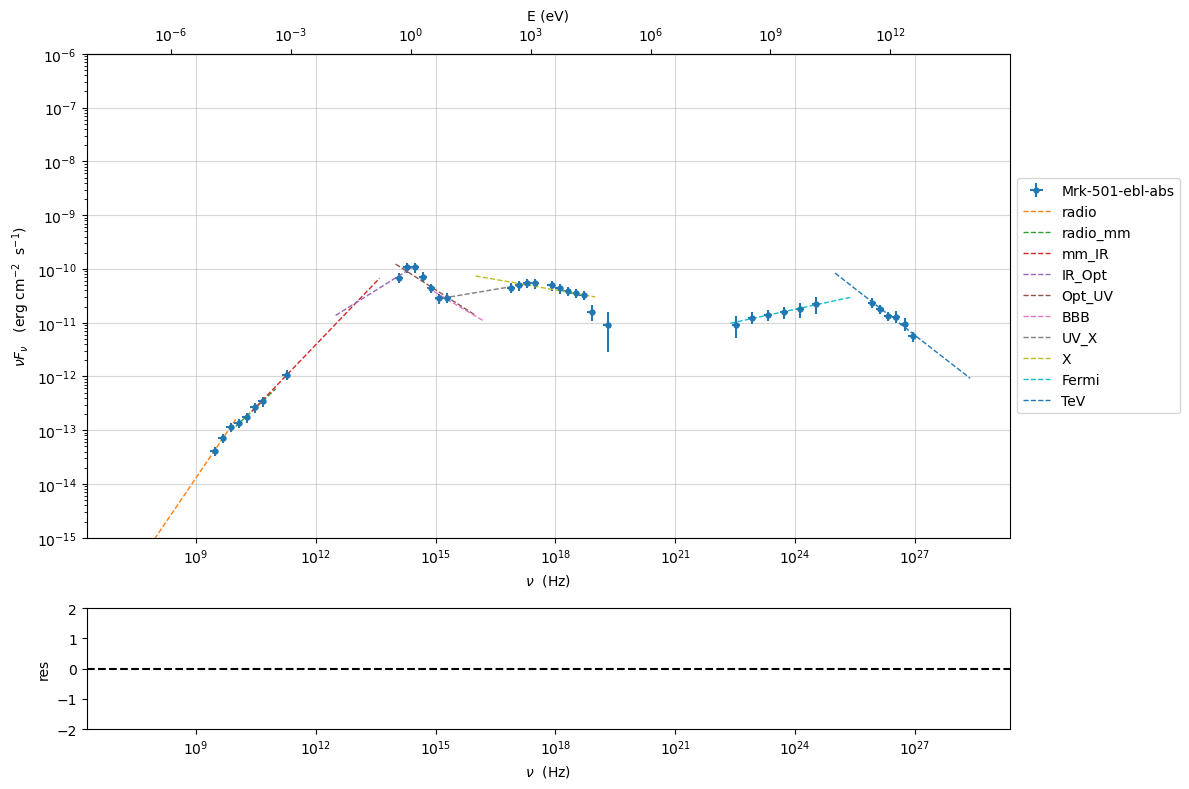

In [7]:
from jetset.sed_shaper import  SEDShape
my_shape=SEDShape(sed_data)
my_shape.eval_indices()
p=my_shape.plot_indices()
p.setlim(y_min=1E-15,y_max=1E-6)


*** Log-Polynomial fitting of the synchrotron component ***
---> first blind fit run,  fit range: [10, 21]
---> class:  HSP

---> class:  HSP




model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-6.329004e-02,-6.329004e-02,1.278183e-02,--,-5.543983e-02,-1.000000e+01,0.000000e+00,False
LogCubic,c,-1.237588e-03,-1.237588e-03,1.932761e-03,--,6.507493e-03,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,1.690035e+01,1.690035e+01,1.625031e-01,--,1.564091e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-1.029659e+01,-1.029659e+01,3.649836e-02,--,-1.017900e+01,-3.000000e+01,0.000000e+00,False
host_galaxy,nuFnu_p_host,-9.970310e+00,-9.970310e+00,6.235472e-02,--,-1.017900e+01,-1.217900e+01,-8.178995e+00,False
host_galaxy,nu_scale,-2.293070e-03,-2.293070e-03,2.252075e-05,--,0.000000e+00,-2.908697e-03,2.908697e-03,False


---> sync       nu_p=+1.690035e+01 (err=+1.625031e-01)  nuFnu_p=-1.029659e+01 (err=+3.649836e-02) curv.=-6.329004e-02 (err=+1.278183e-02)



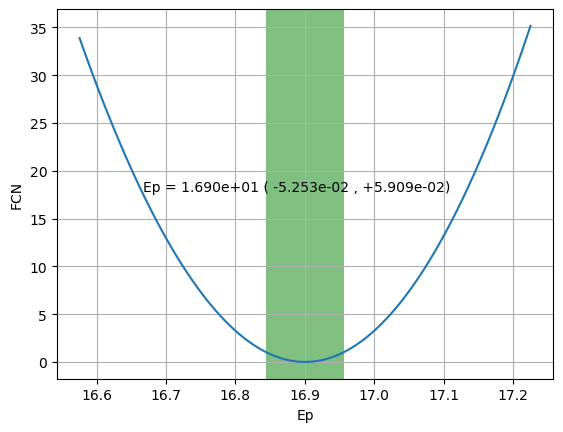

In [8]:
mm,best_fit=my_shape.sync_fit(check_host_gal_template=True,
                  Ep_start=None,
                  minimizer='minuit',
                  silent=True,
                  fit_range=[10,21])

try:
    x,y,z,fig,ax=mm.minimizer.draw_contour('Ep','b')
except:
    pass

try:
    x,y,fig,ax=mm.minimizer.draw_profile('Ep')
except:
    pass


In [9]:
help(mm.minimizer.minos_errors)

Help on method minos_errors in module jetset.minimizer:

minos_errors(par=None) method of jetset.minimizer.MinuitMinimizer instance
    Minos errors.

    Parameters
    ----------
    par : object, optional
        Parameter object or parameter name.




*** Log-Polynomial fitting of the IC component ***
---> fit range: [21, 29]
---> LogCubic fit
-------------------------------------------------------------------------
Fit report

Model: IC-shape-fit


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
LogCubic,b,curvature,,-1.567494e-01,-1.000000e+01,0.000000e+00,False,False
LogCubic,c,third-degree,,-3.842268e-02,-1.000000e+01,1.000000e+01,False,False
LogCubic,Ep,peak freq,Hz,2.522072e+01,0.000000e+00,3.000000e+01,True,False
LogCubic,Sp,peak flux,erg / (s cm2),-1.057106e+01,-3.000000e+01,0.000000e+00,True,False



converged=True
calls=19
mesg=


'`gtol` termination condition is satisfied.'

dof=8
chisq=1.410005, chisq/red=0.176251 null hypothesis sig=0.994103

stats without the UL
dof  UL=8
chisq=1.410005, chisq/red=0.176251 null hypothesis sig=0.994103


best fit pars


model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-1.567494e-01,-1.567494e-01,1.136934e-02,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-3.842268e-02,-3.842268e-02,4.798685e-03,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,2.522072e+01,2.522072e+01,4.892006e-02,--,2.520831e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-1.057106e+01,-1.057106e+01,1.841719e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


-------------------------------------------------------------------------





model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-1.567494e-01,-1.567494e-01,1.136934e-02,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-3.842268e-02,-3.842268e-02,4.798685e-03,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,2.522072e+01,2.522072e+01,4.892006e-02,--,2.520831e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-1.057106e+01,-1.057106e+01,1.841719e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


---> IC         nu_p=+2.522072e+01 (err=+4.892006e-02)  nuFnu_p=-1.057106e+01 (err=+1.841719e-02) curv.=-1.567494e-01 (err=+1.136934e-02)



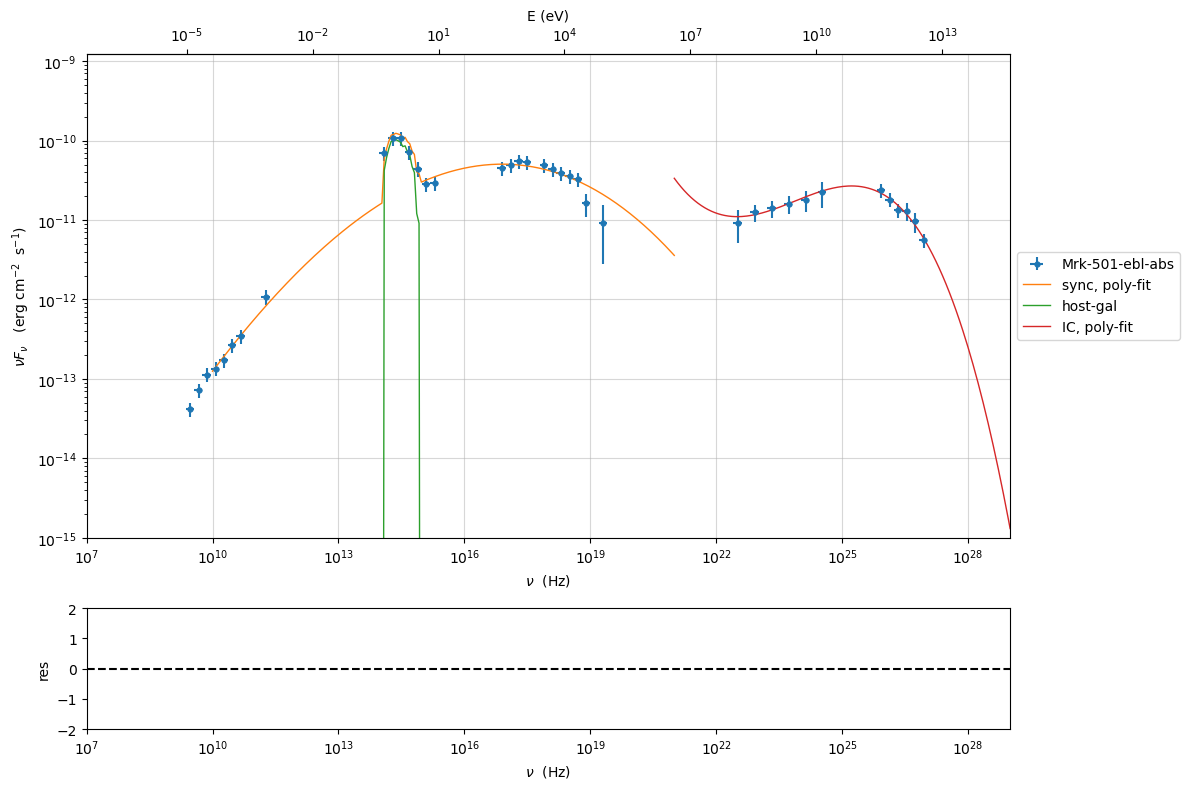

In [10]:
my_shape.IC_fit(fit_range=[21,29],minimizer='lsb')
p=my_shape.plot_shape_fit()
p.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

In [11]:
from jetset.obs_constrain import ObsConstrain
from jetset.model_manager import  FitModel
from jetset.minimizer import fit_SED
sed_obspar=ObsConstrain(beaming=15,
                        B_range=[0.01,0.1],
                        distr_e='lppl',
                        t_var_sec=1*86400,
                        nu_cut_IR=5E10,
                        SEDShape=my_shape)


jet=sed_obspar.constrain_SSC_model(electron_distribution_log_values=True,silent=False)


***  constrains parameters from observable ***


---> ***  emitting region parameters  ***



---> setting par type redshift, corresponding to par z_cosm

---> setting par type magnetic_field, corresponding to par B=5.500000e-02

---> setting par type region_size, corresponding to par R=3.759008e+16
---> completed True


---> *** electron distribution parameters ***
---> emitters distribution spectral type lp
---> emitters distribution name lppl

---> r elec. spec. curvature =3.164502e-01
---> setting par type curvature, corresponding to par r

---> s_radio_mm -0.30143740557836884 1.6028748111567377
---> s_X 3.2605098763768305
---> s_Fermi 1.7437546345348394
---> s_UV_X 2.751533577945437
---> s_Opt_UV -1.4757840745215334 3.9515681490430667
---> s from synch log-log fit -1.0
---> s from (s_Fermi + s_UV)/2
---> power-law index s, class obj=HSP s chosen is 2.247644
---> setting par type LE_spectral_slope, corresponding to par s
---> task completed True

---> setting gamma_3p_Sync= 1.640684e+05, assuming B=5.500000e-02
---> task completed True

---> gamma_max=2.624871e+06 from nu_

/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/obs_constrain.py:1514: RankWarning: Polyfit may be poorly conditioned
  p=polyfit(nu_p_IC_model_log,B_grid_log,2)


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,4.529257e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,3.381593e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.500000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.360000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,2.219954e+00,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,6.524729e+00,0.000000e+00,1.500000e+01,True,False
jet_leptonic,N,emitters_density,1 / cm3,4.644727e+00,0.000000e+00,--,False,False
jet_leptonic,gamma0_log_parab,turn-over-energy,lorentz-factor*,4.131903e+00,0.000000e+00,9.000000e+00,True,False


eval_model




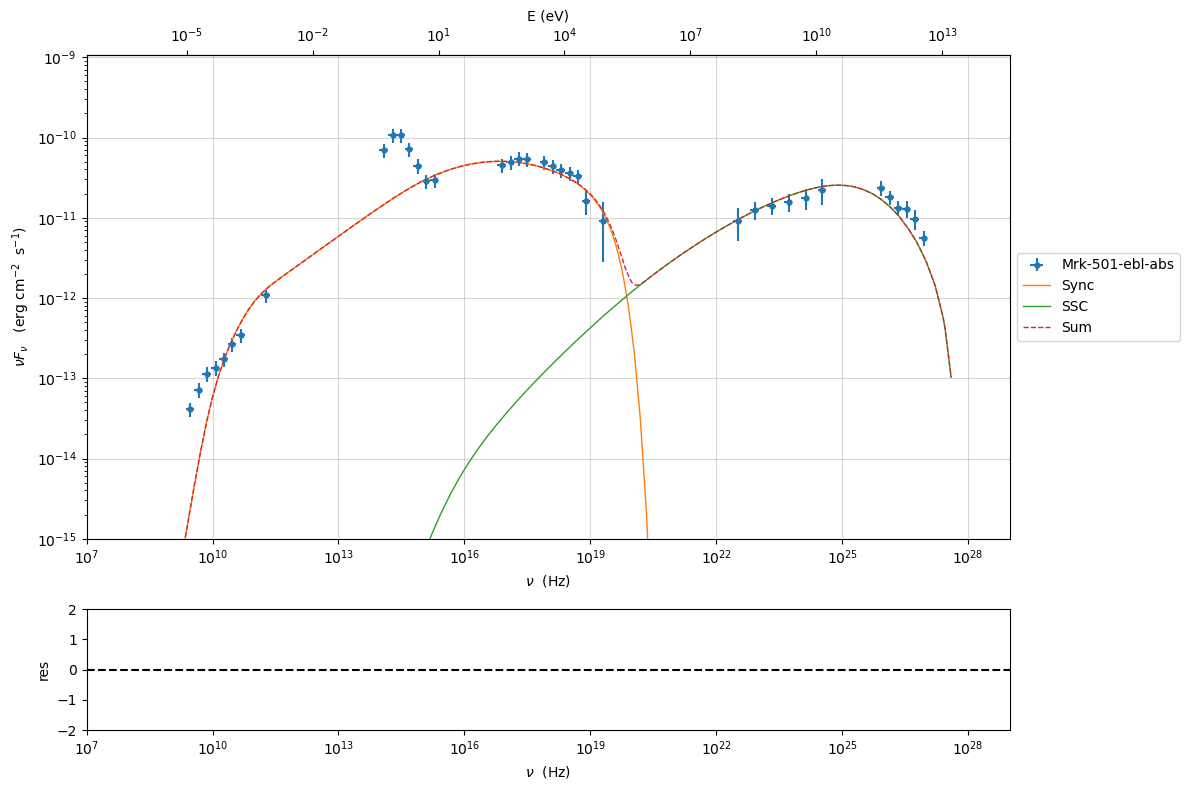

In [12]:
pl=jet.plot_model(sed_data=sed_data)
pl.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)
jet.save_model('constrained_jet.pkl')